# **Analiza tekmovanja za pesem Evrovizije skozi leta**

### **Uvoz knjižnice in začetni testi kode**

In [108]:
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

display(
    HTML(
        "<style>.output_png, .cell-output-display { display: flex; justify-content: center; }</style>"
    )
)

Najprej uvozimo knjižnico in si definiramo nekaj tabel in slovarjev, ki jih bomo tekom analize podatkov potrebovali v veliki meri.

In [109]:
import pandas as pd

df = pd.read_csv("podatki/evrovizija.csv")
pd.set_option("display.max_colwidth", None)

podatki_po_uvedbi_polfinala = df [df ["leto"] >= 2004]
tabela_po_2016 = df [df ["leto"] >= 2016]
tabela_pred_2016 = df [df ["leto"] < 2016]


In [110]:
desetletja = [
    (1956, 1959, "petdeseta"),
    (1960, 1969, "šestdeseta"),
    (1970, 1979, "sedemdeseta"),
    (1980, 1989, "osemdeseta"),
    (1990, 1999, "devetdeseta"),
    (2000, 2009, "gen Z"),
    (2010, 2019, "gen Alpha"),
    (2020, 2026, "gen Beta"),
]

In [111]:
stevilo_finalistov_po_2004 = {
    2004: 36,
    2005: 39,
    2006: 38,
    2007: 42,
    2008: 43,
    2009: 42,
    2010: 39,
    2011: 43,
    2012: 42,
    2013: 39,
    2014: 37,
    2015: 40,
    2016: 42,
    2017: 42,
    2018: 43,
    2019: 41,
    2021: 39,
    2022: 40,
    2023: 37,
    2024: 37,
    2025: 37,
    2026: 35
}

Začetni test, da ugotovimo, ali funkcije delujejo kot morajo. V spodnjem okvirčku spremenite leto, da se vam izpiše tabela s končnimi uvrstitvami držav in izvajalcev v finalu tega leta. 

In [112]:
df[df["leto"] == 2017]

,leto,mesto,drzava,pesem,izvajalec,tocke,tocke_publike,tocke_zirije,startna_stevilka
1231,2017,1,Portugal,Amar pelos dois,Salvador Sobral,758.0,376.0,382.0,11
1232,2017,2,Bulgaria,Beautiful Mess,Kristian Kostov,615.0,337.0,278.0,25
1233,2017,3,Moldova,Hey Mamma,Sunstroke Project,374.0,264.0,110.0,7
1234,2017,4,Belgium,City Lights,Blanche,363.0,255.0,108.0,23
1235,2017,5,Sweden,I Can't Go On,Robin Bengtsson,344.0,126.0,218.0,24
1236,2017,6,Italy,Occidentali's Karma,Francesco Gabbani,334.0,208.0,126.0,9
1237,2017,7,Romania,Yodel It!,Ilinca feat. Alex Florea,282.0,224.0,58.0,20
1238,2017,8,Hungary,Origo,Joci Pápai,200.0,152.0,48.0,8
1239,2017,9,Australia,Don't Come Easy,Isaiah,173.0,2.0,171.0,14
1240,2017,10,Norway,Grab the Moment,Jowst,158.0,29.0,129.0,17


## **Osnovni podatki**

In [77]:
def stevilo_izvedb (datoteka):
    return datoteka ["leto"].nunique ()

st_izvedb = stevilo_izvedb (df)
print (f"Do sedaj se je izvedlo {st_izvedb} izvedb tekmovanja za pesem Evrovizije.")

Do sedaj se je izvedlo 70 izvedb tekmovanja za pesem Evrovizije.


In [78]:
def stevilo_finalistov (datoteka, izbrano_leto):
    if izbrano_leto == 1956:
        return 14
    elif izbrano_leto not in range(1956, 2027):
        return None 
    
    finalisti = datoteka [datoteka ["leto"] == izbrano_leto]
    return len (finalisti)

leto = 1967
st = stevilo_finalistov (df, leto)

if st is None:
    print (f"Izbranega leta ni bilo tekmovanja za pesem Evrovizije. Izberite drugo leto!")
else: 
    print (f"Leta {leto} je bilo v finalu {st} nastopajočih držav.")

Leta 1967 je bilo v finalu 17 nastopajočih držav.


In [79]:
def kolikokrat_je_bila_drzava_v_finalu (datoteka):
    rezultat = datoteka ["drzava"].value_counts ().reset_index ()
    rezultat.columns = ["Država", "Število nastopov v finalu"]
    rezultat.index += 1

    return rezultat

kolikokrat_je_bila_drzava_v_finalu (podatki_po_uvedbi_polfinala)

,Država,Število nastopov v finalu
1,Germany,22
2,France,22
3,United Kingdom,22
4,Sweden,21
5,Spain,21
6,Ukraine,20
7,Greece,19
8,Norway,19
9,Russia,15
10,Romania,15


**Zmagovalci**

In [80]:
def stevilo_zmag (datoteka):
    """Funkcija vrne tabelo držav in število njihovih dosedanjih zmag, pri čemer države z 0 zmagami ignorira."""
    zmagovalci = datoteka [datoteka ["mesto"] == 1]
    tabela = zmagovalci ["drzava"].value_counts ().reset_index ()
    tabela.columns = ["Država", "Število dosedanjih zmag"]
    tabela.index += 1

    return tabela 
    
stevilo_zmag (df)

,Država,Število dosedanjih zmag
1,Ireland,7
2,Sweden,7
3,Netherlands,5
4,France,5
5,Luxembourg,5
6,United Kingdom,5
7,Israel,4
8,Switzerland,3
9,Denmark,3
10,Italy,3


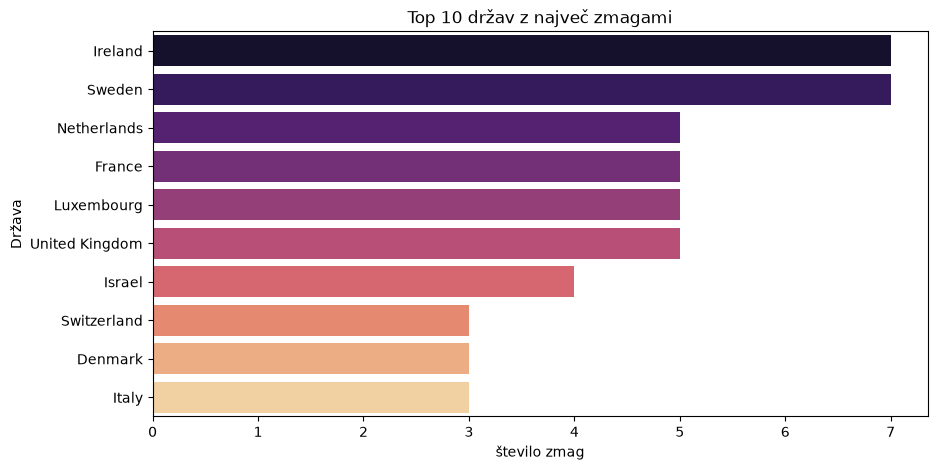

In [81]:
top_zmagovalci = df [df ["mesto"] == 1]["drzava"].value_counts ().head (10)

plt.figure (figsize = (10, 5))
sns.barplot (
    x = top_zmagovalci.values,
    y = top_zmagovalci.index,
    hue = top_zmagovalci.index,
    palette = "magma",
    legend = False
)
plt.title ("Top 10 držav z največ zmagami")
plt.xlabel ("število zmag")
plt.ylabel ("Država")
plt.show ()

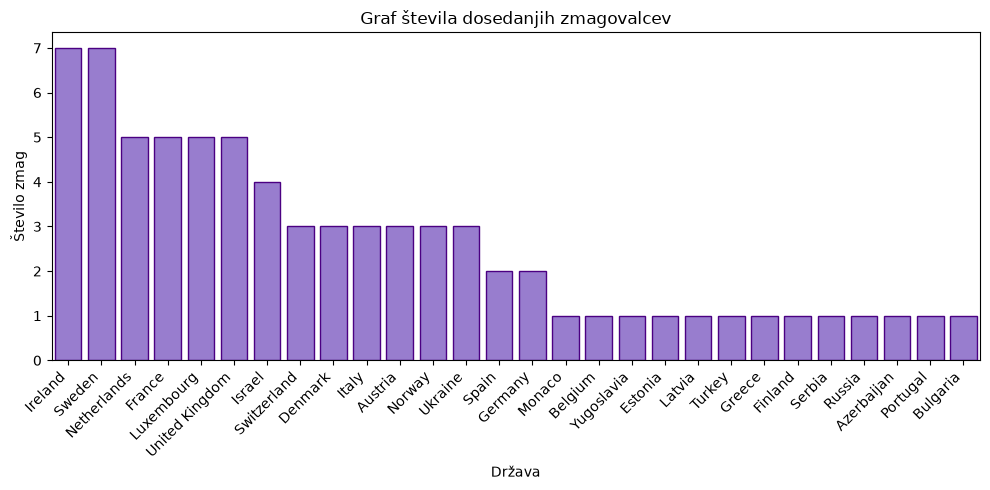

In [82]:
plt.figure (figsize = (10, 5))

sns.barplot (
    data = stevilo_zmag (df), 
    x = "Država",
    y = "Število dosedanjih zmag",
    color = "mediumpurple",
    edgecolor = "indigo"
    )

plt.title ("Graf števila dosedanjih zmagovalcev")
plt.xlabel ("Država")
plt.ylabel ("Število zmag")

plt.xticks (rotation = 45, ha = "right")

plt.tight_layout ()
plt.show ()

In [83]:
def stevilo_zadnjih_mest (datoteka):
    zadnja_mesta = []

    for leto in datoteka ["leto"].unique ():
        podatki_za_leto = datoteka [datoteka ["leto"] == leto]
        zadnje_mesto = podatki_za_leto ["mesto"].max ()
        zadnjeuvrsceni = podatki_za_leto [podatki_za_leto ["mesto"] == zadnje_mesto]
        zadnja_mesta.append (zadnjeuvrsceni)
    tabela_zadnjeuvrscenih = pd.concat (zadnja_mesta)

    rezultat = []

    for drzava in tabela_zadnjeuvrscenih ["drzava"].unique ():
        podatki_drzave = tabela_zadnjeuvrscenih [tabela_zadnjeuvrscenih ["drzava"] == drzava]
        st_zadnjih_mest = len (podatki_drzave)
        seznam_let = list (podatki_drzave ["leto"])
        leta = ", ".join (str (leto) for leto in seznam_let)

        rezultat.append ({
            "Država": drzava,
            "Število zadnjih mest": st_zadnjih_mest,
            "Leta, ko je bila zadnjeuvrščena": leta
        })

    tabela_rezultatov = pd.DataFrame (rezultat)

    max_zadnjih_mest = tabela_rezultatov ["Število zadnjih mest"].max ()
    drzava_max = tabela_rezultatov [tabela_rezultatov ["Število zadnjih mest"] == max_zadnjih_mest]
    vse_drzave = ", ".join (drzava_max ["Država"])

    print (f"Na zadnje mesto se je največkrat uvrstila {vse_drzave} in to kar {max_zadnjih_mest}-krat.")

    return tabela_rezultatov
stevilo_zadnjih_mest (df)

Na zadnje mesto se je največkrat uvrstila Norway in to kar 12-krat.


,Država,Število zadnjih mest,"Leta, ko je bila zadnjeuvrščena"
0,Switzerland,6,"1956, 1964, 1967, 1974, 1998, 2011"
1,Austria,7,"1957, 1961, 1962, 1979, 1984, 1988, 1991"
2,Netherlands,4,"1958, 1962, 1963, 1968"
3,Luxembourg,3,"1958, 1960, 1970"
4,Monaco,2,"1959, 1966"
5,Belgium,8,"1961, 1962, 1965, 1973, 1979, 1985, 1993, 2000"
6,Spain,5,"1962, 1965, 1983, 1999, 2017"
7,Norway,12,"1963, 1969, 1974, 1976, 1978, 1981, 1990, 1997, 2001, 2004, 2012, 2024"
8,Finland,9,"1963, 1965, 1968, 1980, 1982, 1990, 1992, 1996, 2009"
9,Sweden,2,"1963, 1977"


In [84]:
def najvec_tock_po_publiki (datoteka):
    max_st_tock = -1
    maksimalen = None

    for indeks, vrstica in tabela_po_2016.iterrows ():
        if vrstica ["tocke_publike"] > max_st_tock:
            max_st_tock = vrstica ["tocke_publike"]
            maksimalen = vrstica

    rezultat = maksimalen [["leto", "drzava", "izvajalec", "tocke_publike"]]
    rezultat.index = ["Leto", "Država", "Izvajalec", "Točke publike"]
    return rezultat

print (najvec_tock_po_publiki (tabela_po_2016))

Leto                         2022
Država                    Ukraine
Izvajalec        Kalush Orchestra
Točke publike               439.0
Name: 1335, dtype: object


In [85]:
def najvec_tock_po_ziriji (datoteka):
    max_st_tock = -1
    maksimalen = None

    for indeks, vrstica in tabela_po_2016.iterrows ():
        if vrstica ["tocke_zirije"] > max_st_tock:
            max_st_tock = vrstica ["tocke_zirije"]
            maksimalen = vrstica

    rezultat = maksimalen [["leto", "drzava", "izvajalec", "tocke_zirije"]]
    rezultat.index = ["Leto", "Država", "Izvajalec", "Točke žirije"]
    return rezultat

print (najvec_tock_po_ziriji (tabela_po_2016))

Leto                       2017
Država                 Portugal
Izvajalec       Salvador Sobral
Točke žirije              382.0
Name: 1231, dtype: object


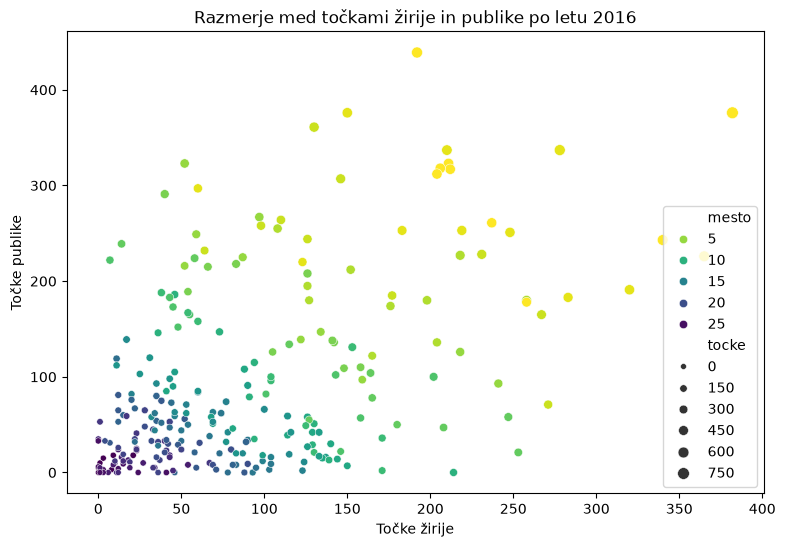

In [86]:
plt.figure (figsize = (9, 6))
sns.scatterplot (
    data = tabela_po_2016,
    x = "tocke_zirije",
    y = "tocke_publike",
    hue = "mesto",
    palette = "viridis_r",
    size = "tocke"
)
plt.title ("Razmerje med točkami žirije in publike po letu 2016")
plt.xlabel ("Točke žirije")
plt.ylabel ("Točke publike")
plt.show ()

In [87]:
def najvec_tock_skupno_po_2016 (datoteka):
    max_st_tock = -1
    maksimalen = None

    for indeks, vrstica in tabela_po_2016.iterrows ():
        if vrstica ["tocke"] > max_st_tock:
            max_st_tock = vrstica ["tocke"]
            maksimalen = vrstica

    rezultat = maksimalen [["leto", "drzava", "izvajalec", "tocke"]]
    rezultat.index = ["Leto", "Država", "Izvajalec", "Skupne točke"]
    return rezultat

print (najvec_tock_skupno_po_2016 (tabela_po_2016))

Leto                       2017
Država                 Portugal
Izvajalec       Salvador Sobral
Skupne točke              758.0
Name: 1231, dtype: object


In [88]:
def najvec_tock_skupno_pred_2016 (datoteka):
    max_st_tock = -1
    maksimalen = None

    for indeks, vrstica in tabela_pred_2016.iterrows ():
        if vrstica ["tocke"] > max_st_tock:
            max_st_tock = vrstica ["tocke"]
            maksimalen = vrstica

    rezultat = maksimalen [["leto", "drzava", "izvajalec", "tocke"]]
    rezultat.index = ["Leto", "Država", "Izvajalec", "Skupne točke"]
    return rezultat

print (najvec_tock_skupno_pred_2016 (tabela_pred_2016))

Leto                       2009
Država                   Norway
Izvajalec       Alexander Rybak
Skupne točke              387.0
Name: 1025, dtype: object


In [89]:
def drzave_z_0_tockami_po_ziriji (datoteka):
    nic_tock_zirije = datoteka [datoteka ["tocke_zirije"] == 0]
    seznam_rezultatov = []

    for drzava in nic_tock_zirije ["drzava"].unique ():
        drzave_z_nic_tc_po_ziriji = nic_tock_zirije [nic_tock_zirije ["drzava"] == drzava]
        stevilo_nic_tock_zirija = len (drzave_z_nic_tc_po_ziriji)
        seznam_let = list (drzave_z_nic_tc_po_ziriji ["leto"])
        leta = ", ".join (str (leto) for leto in seznam_let)

        seznam_rezultatov.append ({
            "Država": drzava,
            "Število 0 točk po žiriji": stevilo_nic_tock_zirija,
            "Leta, ko je osvojila 0 točk": leta
        })

    tabela_rezultatov = pd.DataFrame (seznam_rezultatov)

    return tabela_rezultatov
drzave_z_0_tockami_po_ziriji (tabela_po_2016)

,Država,Število 0 točk po žiriji,"Leta, ko je osvojila 0 točk"
0,Spain,1,2017
1,Israel,1,2019
2,United Kingdom,1,2021
3,Germany,1,2022
4,Iceland,1,2025


In [90]:
def drzave_z_0_tockami_po_publiki (datoteka):
    nic_tock_publike = datoteka [datoteka ["tocke_publike"] == 0]
    seznam_rezultatov = []

    for drzava in nic_tock_publike ["drzava"].unique ():
        drzave_z_nic_tc_po_publiki = nic_tock_publike [nic_tock_publike ["drzava"] == drzava]
        stevilo_nic_tock_publika = len (drzave_z_nic_tc_po_publiki)
        seznam_let = list (drzave_z_nic_tc_po_publiki ["leto"])
        leta = ", ".join (str (leto) for leto in seznam_let)

        seznam_rezultatov.append ({
            "Država": drzava,
            "Število 0 točk po publiki": stevilo_nic_tock_publika,
            "Leta, ko je osvojila 0 točk": leta
        })

    tabela_rezultatov = pd.DataFrame (seznam_rezultatov)

    return tabela_rezultatov
drzave_z_0_tockami_po_publiki (tabela_po_2016)

,Država,Število 0 točk po publiki,"Leta, ko je osvojila 0 točk"
0,Czechia,1,2016
1,Austria,1,2017
2,Germany,3,"2019, 2021, 2026"
3,Netherlands,1,2021
4,Spain,1,2021
5,United Kingdom,4,"2021, 2024, 2025, 2026"
6,Switzerland,2,"2022, 2025"
7,Belgium,1,2026


In [91]:
def drzave_z_0_tockami_v_finalu (datoteka):
    nic_tock = datoteka [datoteka ["tocke"] == 0]
    seznam_rezultatov = []

    for drzava in nic_tock ["drzava"].unique ():
        drzave_z_nic_tc = nic_tock [nic_tock ["drzava"] == drzava]
        stevilo_nic_tock = len (drzave_z_nic_tc)
        seznam_let = list (drzave_z_nic_tc ["leto"])
        leta = ", ".join (str (leto) for leto in seznam_let)

        seznam_rezultatov.append ({
            "Država": drzava,
            "Število 0 točk": stevilo_nic_tock,
            "Leta, ko je osvojila 0 točk": leta
        })

    tabela_rezultatov = pd.DataFrame (seznam_rezultatov)

    maksimalno_st_nicel = tabela_rezultatov ["Število 0 točk"].max ()
    drzave_z_max_0_tockami = tabela_rezultatov [tabela_rezultatov ["Število 0 točk"] == maksimalno_st_nicel]
    imena_teh_drzav = " in ".join (drzave_z_max_0_tockami ["Država"])

    print (f"Od leta 1956 do sedaj sta rekorderki po številu osvojenih 0 točk v finalu {imena_teh_drzav}, ki sta to 'lovoriko' osvojili {maksimalno_st_nicel}-krat.")

    return tabela_rezultatov
drzave_z_0_tockami_v_finalu (df)

Od leta 1956 do sedaj sta rekorderki po številu osvojenih 0 točk v finalu Austria in Norway, ki sta to 'lovoriko' osvojili 4-krat.


,Država,Število 0 točk,"Leta, ko je osvojila 0 točk"
0,Belgium,2,"1962, 1965"
1,Spain,3,"1962, 1965, 1983"
2,Austria,4,"1962, 1988, 1991, 2015"
3,Netherlands,2,"1962, 1963"
4,Norway,4,"1963, 1978, 1981, 1997"
5,Finland,3,"1963, 1965, 1982"
6,Sweden,1,1963
7,Germany,3,"1964, 1965, 2015"
8,Portugal,2,"1964, 1997"
9,Yugoslavia,1,1964


In [92]:
def odstotek_0_tock (datoteka):
    tabela_zadnjih = stevilo_zadnjih_mest (datoteka)
    rezultat = []

    for indeks, vrstica in tabela_zadnjih.iterrows ():
        drzava = vrstica ["Država"]
        st_zadnjih = vrstica ["Število zadnjih mest"]

        delez = len (datoteka [(datoteka ["drzava"] == drzava) & (datoteka ["tocke"] == 0)])
        odstotek = (delez / st_zadnjih) * 100

        rezultat.append ({
            "Država": drzava,
            "Odstotek 0 točk na zadnjem mestu": f"{odstotek:.2f} %"
        })

    tabela_rezultatov = pd.DataFrame (rezultat)
    return tabela_rezultatov
odstotek_0_tock (df)

Na zadnje mesto se je največkrat uvrstila Norway in to kar 12-krat.


,Država,Odstotek 0 točk na zadnjem mestu
0,Switzerland,50.00 %
1,Austria,57.14 %
2,Netherlands,50.00 %
3,Luxembourg,33.33 %
4,Monaco,50.00 %
5,Belgium,25.00 %
6,Spain,60.00 %
7,Norway,33.33 %
8,Finland,33.33 %
9,Sweden,50.00 %


In [93]:
def vecno_drugi (datoteka):
    drugo_mesto = datoteka [datoteka ["mesto"] == 2]
    rezultat = []

    for drzava in drugo_mesto ["drzava"].unique ():
        podatki_drzave = drugo_mesto [drugo_mesto ["drzava"] == drzava]
        st_drugih_mest = len (podatki_drzave)
        seznam_let = list (podatki_drzave ["leto"])
        leta = ", ".join (str (leto) for leto in seznam_let)

        rezultat.append ({
            "Država": drzava,
            "Število drugih mest": st_drugih_mest,
            "Leta, ko je osvojila drugo mesto": leta
        })

    tabela_rezultatov = pd.DataFrame (rezultat)
    tabela_rezultatov = tabela_rezultatov.sort_values (by = "Število drugih mest", ascending = False)
    tabela_rezultatov_top_5 = tabela_rezultatov.head (5)
    tabela_rezultatov_top_5.index = range (1, 6)

    return tabela_rezultatov_top_5
vecno_drugi (df)


,Država,Število drugih mest,"Leta, ko je osvojila drugo mesto"
1,United Kingdom,16,"1959, 1960, 1961, 1964, 1965, 1968, 1970, 1972, 1975, 1977, 1988, 1989, 1992, 1993, 1998, 2022"
2,France,5,"1957, 1976, 1990, 1991, 2021"
3,Ireland,4,"1967, 1984, 1990, 1997"
4,Spain,4,"1971, 1973, 1979, 1995"
5,Russia,4,"2000, 2006, 2012, 2015"


In [94]:
def analiza_zmagovalcev_po_2016 (datoteka):
    rezultat = []

    for leto in sorted (tabela_po_2016 ["leto"].unique ()):
        podatki_leta = tabela_po_2016 [tabela_po_2016 ["leto"] == leto]
        skupni_zmagovalec = podatki_leta [podatki_leta ["mesto"] == 1]["drzava"].values [0]
        zmagovalec_zirije = podatki_leta.sort_values (by = "tocke_zirije", ascending = False) ["drzava"].values [0]
        zmagovalec_publike = podatki_leta.sort_values (by = "tocke_publike", ascending = False) ["drzava"].values [0]

        if skupni_zmagovalec == zmagovalec_zirije and skupni_zmagovalec == zmagovalec_publike:
            status = "Žirija in publika"
        elif skupni_zmagovalec == zmagovalec_zirije:
            status = "Samo žirija"
        elif skupni_zmagovalec == zmagovalec_publike:
            status = "Samo publika"
        else:
            status = "Nihče"

        rezultat.append ({
            "Leto": leto,
            "Skupni zmagovalec": skupni_zmagovalec,
            "Kdo ga je izbral": status
        })

    tabela_rezultatov = pd.DataFrame (rezultat)
    tabela_rezultatov.index = range (1, len (tabela_rezultatov) + 1)

    return tabela_rezultatov

analiza_zmagovalcev_po_2016 (tabela_po_2016)

,Leto,Skupni zmagovalec,Kdo ga je izbral
1,2016,Ukraine,Nihče
2,2017,Portugal,Žirija in publika
3,2018,Israel,Samo publika
4,2019,Netherlands,Nihče
5,2021,Italy,Samo publika
6,2022,Ukraine,Samo publika
7,2023,Sweden,Samo žirija
8,2024,Switzerland,Samo žirija
9,2025,Austria,Samo žirija
10,2026,Bulgaria,Žirija in publika


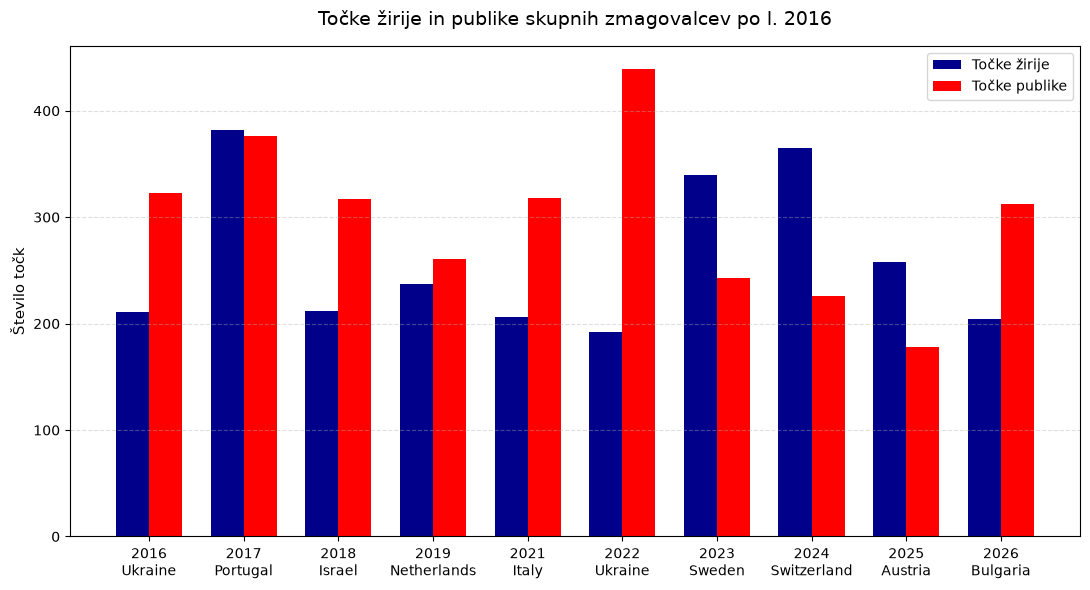

In [95]:
def graf_tock_zmagovalcev (tabela_po_2016):
    podatki_zmagovalcev = []

    for leto in sorted (tabela_po_2016 ["leto"].unique ()):
        podatki_leta = tabela_po_2016 [tabela_po_2016 ["leto"] == leto]
        zmagovalec = podatki_leta [podatki_leta ["mesto"] == 1].iloc [0]

        podatki_zmagovalcev.append ({
            "Leto": leto,
            "Država": zmagovalec ["drzava"],
            "Žirija": zmagovalec ["tocke_zirije"],
            "Publika": zmagovalec ["tocke_publike"]
        })

    tabela_zmag = pd.DataFrame (podatki_zmagovalcev)

    x = np.arange (len (tabela_zmag))
    sirina = 0.35
    fig, ax = plt.subplots (figsize = (11, 6))
    stolpci_zirije = ax.bar (
        x - sirina / 2,
        tabela_zmag ["Žirija"],
        sirina,
        label = "Točke žirije",
        color = "darkblue",
    )
    stolpci_publike = ax.bar (
        x + sirina / 2,
        tabela_zmag ["Publika"],
        sirina,
        label = "Točke publike",
        color = "red",
    )
    ax.set_title (
        "Točke žirije in publike skupnih zmagovalcev po l. 2016",
        fontsize = 14,
        pad = 15,
        )
    ax.set_ylabel ("Število točk", fontsize = 11)
    oznake = [
        f"{leto}\n{drzava}" for leto, drzava in zip (tabela_zmag ["Leto"], tabela_zmag ["Država"])
    ]
    ax.set_xticks (x)
    ax.set_xticklabels (oznake, fontsize = 10)
    ax.legend ()
    ax.grid (axis = "y", linestyle = "--", alpha = 0.4)
    plt.tight_layout ()
    plt.show ()

graf_tock_zmagovalcev (tabela_po_2016)


In [96]:
def najboljsa_povprecna_uvrstitev (datoteka, minimum_nastopov = 10):
    rezultat = []

    for drzava in datoteka ["drzava"].unique ():
        podatki_drzave = datoteka [datoteka ["drzava"] == drzava]
        stevilo_nastopov = len (podatki_drzave)

        if stevilo_nastopov >= minimum_nastopov:
            povprecno_mesto = podatki_drzave ["mesto"].mean ()
            rezultat.append ({
                "Država": drzava,
                "Število nastopov": stevilo_nastopov,
                "Povprečna uvrstitev v finalu": round (povprecno_mesto, 2)
            })

    tabela = pd.DataFrame (rezultat)
    tabela = tabela.sort_values (by = "Povprečna uvrstitev v finalu", ascending = True).head (10)
    tabela.index = range (1, len (tabela) + 1)

    return tabela

najboljsa_povprecna_uvrstitev (df)

,Država,Število nastopov,Povprečna uvrstitev v finalu
1,Italy,50,7.22
2,Monaco,21,7.38
3,Russia,22,7.68
4,Ukraine,21,8.10
5,Sweden,64,8.41
6,Ireland,46,8.80
7,Luxembourg,38,9.63
8,Israel,41,9.80
9,United Kingdom,68,10.07
10,France,67,10.12


In [97]:
def najuspesnejsa_startna_stevilka (datoteka):
    zmagovalci = datoteka [datoteka ["mesto"] == 1]
    zmage = len (zmagovalci)
    rezultat = []

    for startna_stevilka in sorted (zmagovalci ["startna_stevilka"].unique ()):
        stevilo_zmag = len (zmagovalci [zmagovalci ["startna_stevilka"] == startna_stevilka])
        odstotek_zmag = (stevilo_zmag / zmage) * 100

        rezultat.append ({
            "Štartna številka": int (startna_stevilka),
            "Število zmag": stevilo_zmag,
            "Odstotek zmag": f"{odstotek_zmag:.2f} %"
        })

    tabela_rezultatov = pd.DataFrame (rezultat)
    tabela_rezultatov = tabela_rezultatov.sort_values (by = "Število zmag", ascending = False)
    tabela_rezultatov.index = range (1, len (tabela_rezultatov) + 1)

    vse_startne_stevilke = set (datoteka ["startna_stevilka"].dropna ().unique ())
    zmagovalne_stevilke = set (zmagovalci ["startna_stevilka"].unique ())
    nezmagovalne_stevilke = sorted ([int (st) for st in (vse_startne_stevilke - zmagovalne_stevilke)])
    nezmagovalci = ", ".join (map (str, nezmagovalne_stevilke))
    
    print (f"Štartne številke, ki še nikoli niso prinesle zmage, so {nezmagovalci}.")
    return tabela_rezultatov
    

najuspesnejsa_startna_stevilka (df)

Štartne številke, ki še nikoli niso prinesle zmage, so 2, 16, 25, 26, 27.


,Štartna številka,Število zmag,Odstotek zmag
1,17,7,9.59 %
2,9,6,8.22 %
3,8,5,6.85 %
4,12,5,6.85 %
5,14,5,6.85 %
6,20,4,5.48 %
7,18,4,5.48 %
8,11,4,5.48 %
9,3,4,5.48 %
10,1,3,4.11 %


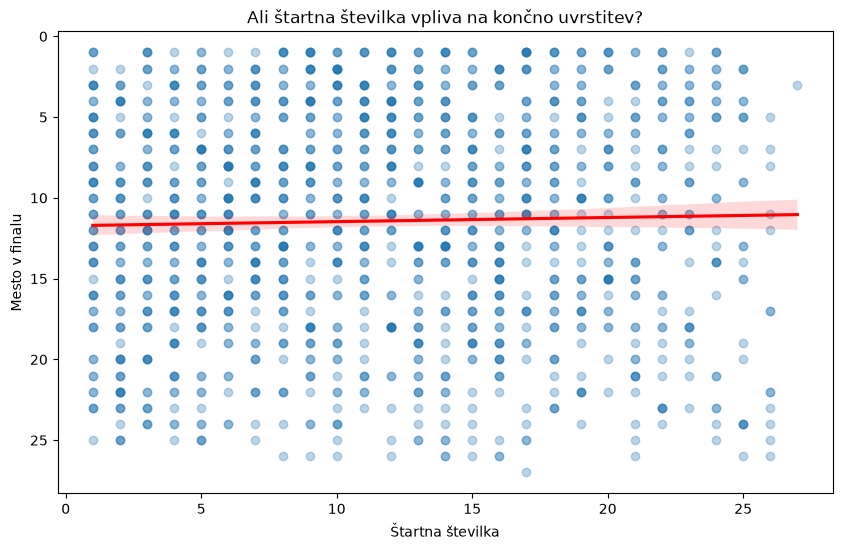

In [98]:
plt.figure (figsize = (10, 6))
sns.regplot (
    data = df,
    x = "startna_stevilka",
    y = "mesto",
    scatter_kws = {"alpha": 0.3},
    line_kws = {"color": "red"}
)
plt.gca ().invert_yaxis () # 1. mesto je na vrhu
plt.title ("Ali štartna številka vpliva na končno uvrstitev?")
plt.xlabel ("Štartna številka")
plt.ylabel ("Mesto v finalu")
plt.show ()

In [99]:
def najvisji_odstotek_zmagovalnih_točk (datoteka):
    zmagovalci = datoteka [datoteka ["mesto"] == 1]
    rezultat = []

    for leto in sorted (zmagovalci ["leto"].unique ()):
        podatki_leta = datoteka [datoteka ["leto"] == leto]
        zmagovalec = podatki_leta [podatki_leta ["mesto"] == 1].iloc [0]

        dosezene_tocke_izvajalca = zmagovalec ["tocke"]

        # 1956 nima objavljenih točk 
        if dosezene_tocke_izvajalca != dosezene_tocke_izvajalca or dosezene_tocke_izvajalca is None:
            continue

        stevilo_glasov = stevilo_finalistov_po_2004.get(leto, len(podatki_leta))
        
        if leto < 2016:
            max_tock_drzave = 12
        else:
           max_tock_drzave = 24
        
        vse_mozne_tocke = (stevilo_glasov - 1) * max_tock_drzave

        if vse_mozne_tocke == 0:
            continue
        
        odstotek_dosezenih_tock = (dosezene_tocke_izvajalca / vse_mozne_tocke) * 100

        rezultat.append ({
            "Izvajalec": zmagovalec ["izvajalec"],
            "Pesem": zmagovalec ["pesem"],
            "Leto": int (leto),
            "Število doseženih točk": int(dosezene_tocke_izvajalca),
            "Odstotek možnih točk": f"{odstotek_dosezenih_tock:.2f} %",
            "_odstotek_pomozni": odstotek_dosezenih_tock
        })

    tabela_rezultatov = pd.DataFrame (rezultat)
    tabela_rezultatov = tabela_rezultatov.sort_values (by = "_odstotek_pomozni", ascending = False).head (10)
    tabela_rezultatov = tabela_rezultatov.drop (columns = ["_odstotek_pomozni"])
    tabela_rezultatov.index = range (1, len (tabela_rezultatov) + 1)

    return tabela_rezultatov

najvisji_odstotek_zmagovalnih_točk (df)

,Izvajalec,Pesem,Leto,Število doseženih točk,Odstotek možnih točk
1,Brotherhood of Man,Save Your Kisses for Me,1976,164,80.39 %
2,Nicole,Ein bißchen Frieden,1982,161,78.92 %
3,Katrina and The Waves,Love Shine A Light,1997,227,78.82 %
4,Alexander Rybak,Fairytale,2009,387,78.66 %
5,Paul Harrington & Charlie McGettigan,Rock 'n' Roll Kids,1994,226,78.47 %
6,Måns Zelmerlöw,Heroes,2015,365,77.99 %
7,Sandra Kim,J'aime la vie,1986,176,77.19 %
8,Salvador Sobral,Amar pelos dois,2017,758,77.03 %
9,Loreen,Euphoria,2012,372,75.61 %
10,"Tanel Padar, Dave Benton & 2XL",Everybody,2001,198,75.00 %


In [100]:
def relativni_indeks_uspešnosti (datoteka, minimum_nastopov = 10):
    """Pri tej metodi za vsak nastop izračunamo, kolikšen odstotek tekmencev je država premagala v tistem finalu: 1. mesto med 26 tekmovalci = 100% uspešnost. 
    13. mesto med 26 tekmovalci = 53.8% uspešnost. Zadnje mesto = najnižji odstotek.
    Nato izračunamo povprečni indeks uspešnosti skozi vso zgodovino. S tem popolnoma nevtraliziramo vse spremembe točkovnih sistemov in različna števila finalistov."""

    rezultat = []

    for drzava in datoteka ["drzava"].unique ():
        podatki_drzave = datoteka [datoteka ["drzava"] == drzava]
        stevilo_nastopov = len (podatki_drzave)

        if stevilo_nastopov >= minimum_nastopov:
            vsota = 0

            for _, vrstica in podatki_drzave.iterrows ():
                leto = vrstica ["leto"]
                mesto = vrstica ["mesto"]
                stevilo_finalistov = len (datoteka [datoteka ["leto"] == leto])

                # Indeks: 1. mesto dobi 100 %, zadnje mesto dobi (1 / st_finalistov) * 100 %
                indeks_relativnosti = ((stevilo_finalistov - mesto + 1) / stevilo_finalistov) * 100
                vsota += indeks_relativnosti

            povprecni_indeks_relativnosti = vsota / stevilo_nastopov

            rezultat.append ({
                "Država": drzava,
                "Število nastopov": stevilo_nastopov,
                "Relativna uspešnost": f"{povprecni_indeks_relativnosti:.2f} %",
                "_pomozni_rel_indeks": povprecni_indeks_relativnosti
            })

    tabela_rezultatov = pd.DataFrame (rezultat)
    tabela_rezultatov = tabela_rezultatov.sort_values (by = "_pomozni_rel_indeks", ascending = False).head (10)
    tabela_rezultatov = tabela_rezultatov.drop (columns = ["_pomozni_rel_indeks"])
    tabela_rezultatov.index = range (1, len (tabela_rezultatov) + 1)

    return tabela_rezultatov

relativni_indeks_uspešnosti (df)

,Država,Število nastopov,Relativna uspešnost
1,Russia,22,72.75 %
2,Ukraine,21,72.08 %
3,Italy,50,67.46 %
4,Azerbaijan,13,64.58 %
5,Ireland,46,64.40 %
6,Sweden,64,64.22 %
7,Israel,41,62.03 %
8,United Kingdom,68,61.42 %
9,Monaco,21,61.19 %
10,Estonia,20,60.70 %


**Državno**

In [101]:
def najuspešnejši_predstavniki (datoteka):
    rezultat = []

    for drzava in sorted (datoteka ["drzava"].unique ()):
        podatki_drzave = datoteka [datoteka ["drzava"] == drzava]
        najboljsi_predstavnik = podatki_drzave.sort_values (
            by = ["mesto", "tocke"], ascending = [True, False]).iloc [0]

        mesto = najboljsi_predstavnik ["mesto"]
        prikaz = f"🏆 {mesto}" if mesto == 1 else str (mesto)

        rezultat.append ({
            "Država": drzava,
            "Izvajalec": najboljsi_predstavnik ["izvajalec"],
            "Pesem": najboljsi_predstavnik ["pesem"],
            "Leto": najboljsi_predstavnik ["leto"],
            "Končna uvrstitev": prikaz
        })

    tabela_rezultatov = pd.DataFrame (rezultat)
    tabela_rezultatov.index = range (1, len (tabela_rezultatov) + 1)

    return tabela_rezultatov

najuspešnejši_predstavniki (df)

,Država,Izvajalec,Pesem,Leto,Končna uvrstitev
1,Albania,Rona Nishliu,Suus,2012,5
2,Armenia,Sirusho,"Qele, qele",2008,4
3,Australia,Dami Im,Sound of Silence,2016,2
4,Austria,JJ,Wasted Love,2025,🏆 1
5,Azerbaijan,Ell/Nikki,Running Scared,2011,🏆 1
6,Belarus,Dmitry Koldun,Work Your Magic,2007,6
7,Belgium,Sandra Kim,J'aime la vie,1986,🏆 1
8,Bosnia & Herzegovina,Hari Mata Hari,Lejla,2006,3
9,Bulgaria,Dara,Bangaranga,2026,🏆 1
10,Croatia,Baby Lasagna,Rim Tim Tagi Dim,2024,2


In [102]:
def najboljsa_drzava_desetletja (datoteka, minimum_nastopov = 4):
    rezultat = []

    for zacetek, konec, oznaka in desetletja:
        podatki_desetletja = datoteka [(datoteka ["leto"] >= zacetek) & (datoteka ["leto"] <= konec)]

        if podatki_desetletja.empty:
            continue

        statistika_drzave = []

        for drzava in podatki_desetletja ["drzava"].unique ():
            podatki_drzave = podatki_desetletja [podatki_desetletja ["drzava"] == drzava]
            stevilo_nastopov = len (podatki_drzave)

            if stevilo_nastopov >= minimum_nastopov:
                povprecno_mesto = podatki_drzave ["mesto"].mean ()

                statistika_drzave.append ({
                    "drzava": drzava,
                    "nastopi": stevilo_nastopov,
                    "povprecje": povprecno_mesto
                })
        if statistika_drzave:
            tabela = pd.DataFrame (statistika_drzave)
            najboljsa_drzava = tabela.sort_values (by = "povprecje").iloc [0]

            rezultat.append ({
                "Desetletje": oznaka,
                "Država": najboljsa_drzava ["drzava"],
                "Število nastopov": najboljsa_drzava ["nastopi"],
                "Povprečna uvrstitev": round (najboljsa_drzava ["povprecje"], 2)
            })

    tabela_rezultatov = pd.DataFrame (rezultat)
    tabela_rezultatov.index = range (1, len (tabela_rezultatov) + 1)

    return tabela_rezultatov

najboljsa_drzava_desetletja (df)

,Desetletje,Država,Število nastopov,Povprečna uvrstitev
1,petdeseta,Switzerland,4,3.75
2,šestdeseta,United Kingdom,10,2.90
3,sedemdeseta,United Kingdom,10,3.80
4,osemdeseta,United Kingdom,10,5.20
5,devetdeseta,Italy,5,5.60
6,gen Z,Russia,10,7.00
7,gen Alpha,Sweden,9,4.89
8,gen Beta,Italy,6,4.67


**Ostalo**

In [103]:
def beseda_love (datoteka):
    naslovi_pesmi = datoteka ["pesem"]
    stevilo_naslovov = len (naslovi_pesmi)
    pojavitve = 0

    for naslov in naslovi_pesmi:
        naslov_besedila = str(naslov).lower ()

        for locilo in [".", ",", "!", "?", "-", ":", ";", "(", ")", '"', "'"]:
            naslov_besedila = naslov_besedila.replace (locilo, " ")

        besede = naslov_besedila.split ()

        if "love" in besede:
            pojavitve += 1

    odstotek_love = (pojavitve / stevilo_naslovov) * 100

    print (f"Število naslovov pesmi, ki vsebujejo besedo 'love', je {pojavitve}, kar predstavlja {odstotek_love:.2f} odstotkov vseh naslovov.")

    #return pojavitve, round (odstotek_love, 2)
beseda_love (df)

Število naslovov pesmi, ki vsebujejo besedo 'love', je 57, kar predstavlja 3.90 odstotkov vseh naslovov.


In [104]:
def uspešnost_pesmi_z_besedo_love (datoteka):
    pojavitev_love = 0
    zmage_love = 0

    for indeks, vrstica in datoteka.iterrows ():
        naslov = str (vrstica ["pesem"]).lower ()
        for locilo in [".", ",", "!", "?", "-", ":", ";", "(", ")", '"', "'"]:
            naslov = naslov.replace (locilo, " ")
        besede = naslov.split ()

        if "love" in besede:
            pojavitev_love += 1
            if vrstica ["mesto"] == 1:
                zmage_love += 1
    odstotek = (zmage_love / pojavitev_love) * 100

    print (f"Od {pojavitev_love} pesmi z besedo 'love' v naslovu je zmagalo {zmage_love} takih pesmi, kar pomeni {odstotek:.2} % uspešnost.")

uspešnost_pesmi_z_besedo_love (df)


Od 57 pesmi z besedo 'love' v naslovu je zmagalo 3 takih pesmi, kar pomeni 5.3 % uspešnost.


In [105]:
def izvajalci_ki_so_nastopili_veckrat (datoteka):
    rezultat = []

    for izvajalec in datoteka ["izvajalec"].unique ():
        podatki_izvajalca = datoteka [datoteka ["izvajalec"] == izvajalec]
        stevilo_nastopov = len (podatki_izvajalca)

        if stevilo_nastopov > 1:
            seznam_let = list (podatki_izvajalca ["leto"])
            leta = ", ".join (str (leto) for leto in seznam_let)

            rezultat.append ({
                "Izvajalec": izvajalec,
                "Število nastopov": stevilo_nastopov,
                "Leta, v katerih je nastopil": leta
            })

    tabela_rezultatov = pd.DataFrame (rezultat)
    tabela_rezultatov.index = range (1, len (tabela_rezultatov) + 1)
#    pd.set_option("display.max_rows", None)
    return tabela_rezultatov

izvajalci_ki_so_nastopili_veckrat (df)

,Izvajalec,Število nastopov,"Leta, v katerih je nastopil"
1,Lys Assia,3,"1956, 1957, 1958"
2,Corry Brokken,2,"1957, 1958"
3,Margot Hielscher,2,"1957, 1958"
4,Domenico Modugno,3,"1958, 1959, 1966"
5,Fud Leclerc,3,"1958, 1960, 1962"
...,...,...,...
77,Jedward,2,"2011, 2012"
78,Loreen,2,"2012, 2023"
79,Donny Montell,2,"2012, 2016"
80,Marco Mengoni,2,"2013, 2023"


In [106]:
def meddrzavno_povezovanje (datoteka):
    rezultat = []

    for izvajalec in datoteka ["izvajalec"].unique ():
        podatki_o_izvajalcu = datoteka [datoteka ["izvajalec"] == izvajalec]
        drzave_nastopov = list (podatki_o_izvajalcu ["drzava"].unique ())
        stevilo_drzav = len (drzave_nastopov)

        if stevilo_drzav > 1:
            drzave = ", ".join (drzave_nastopov)

            rezultat.append ({
                "Izvajalec": izvajalec,
                "Število držav": stevilo_drzav,
                "Države, ki jih je zastopal": drzave
            })

    tabela_rezultatov = pd.DataFrame (rezultat)
    tabela_rezultatov.index = range (1, len (tabela_rezultatov) + 1)

    return tabela_rezultatov

meddrzavno_povezovanje (df)

,Izvajalec,Število držav,"Države, ki jih je zastopal"
1,Jean Philippe,2,"France, Switzerland"
2,Siw Malmkvist,2,"Sweden, Germany"
3,Romuald,2,"Monaco, Luxembourg"
4,Michèle Torr,2,"Luxembourg, Monaco"
5,Géraldine,2,"Switzerland, Luxembourg"
6,Anne-Marie David,2,"Luxembourg, France"
7,Ireen Sheer,2,"Luxembourg, Germany"
8,Elpida,2,"Greece, Cyprus"
9,Anna Vissi,2,"Cyprus, Greece"
10,Doris Dragović,2,"Yugoslavia, Croatia"
